<a href="https://colab.research.google.com/github/rf-pharma/project-superstore-datasets-/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
#load the data
url="https://github.com/rf-pharma/project-superstore-datasets-/raw/refs/heads/main/Sample%20store.csv"
df = pd.read_csv(url, encoding='latin1')
# show the first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [34]:
# check data typr and structure
df.info()
#statistics summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [35]:
#identify missing value
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


There is no missing value in the data set

In [36]:
# Convert Order Date and Ship Date to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Verify the change
print(df.dtypes[['Order Date', 'Ship Date']])

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [37]:
# Extract Month and Year from Order Date
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

# Create a new column: Profit Margin
df['Profit Margin'] = df['Profit'] / df['Sales']

# Verify the new columns
print(df[['Sales', 'Profit', 'Profit Margin']].head())

      Sales    Profit  Profit Margin
0  261.9600   41.9136         0.1600
1  731.9400  219.5820         0.3000
2   14.6200    6.8714         0.4700
3  957.5775 -383.0310        -0.4000
4   22.3680    2.5164         0.1125


In [38]:
# total sales by category
s_by_c=df.groupby('Category')['Sales'].sum()
print(s_by_c)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [39]:
#total profit by region
p_by_r=df.groupby('Region')['Profit'].sum()
print(p_by_r)

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


In [40]:
#top 5 customers by sales
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head()

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571


In [41]:
# monthly sales trends
monthly_sales_trends=df.groupby(['Year', 'Month'])['Sales'].sum()
print(monthly_sales_trends)

Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999.0430
2017  1         

In [42]:
#sales by category and region
piv1=df.pivot_table(index='Category', columns='Region', values='Sales', aggfunc='sum')
print(piv1)

Region               Central        East       South         West
Category                                                         
Furniture        163797.1638  208291.204  117298.684  252612.7435
Office Supplies  167026.4150  205516.055  125651.313  220853.2490
Technology       170416.3120  264973.981  148771.908  251991.8320


In [43]:
#sales trends by segment over time
piv2=df.pivot_table(index='Order Date', columns='Segment', values='Sales', aggfunc='sum')
print(piv2)

Segment      Consumer  Corporate  Home Office
Order Date                                   
2014-01-03    16.4480        NaN          NaN
2014-01-04        NaN        NaN      288.060
2014-01-05    19.5360        NaN          NaN
2014-01-06    19.4400     12.780     4374.880
2014-01-07    87.1580        NaN          NaN
...               ...        ...          ...
2017-12-26    44.7500    766.712        3.132
2017-12-27        NaN    177.636          NaN
2017-12-28   363.0748   1201.112       93.164
2017-12-29  2604.7140    310.820          NaN
2017-12-30   469.8660     34.624      209.300

[1237 rows x 3 columns]


In [44]:
#profit by sub_category
piv3=df.pivot_table(index='Sub-Category', columns='Profit', values='Sales', aggfunc='sum')

print(piv3)

Profit        -6599.9780  -3839.9904  -3701.8928  -3399.9800  -2929.4845  \
Sub-Category                                                               
Accessories          NaN         NaN         NaN         NaN         NaN   
Appliances           NaN         NaN         NaN         NaN         NaN   
Art                  NaN         NaN         NaN         NaN         NaN   
Binders              NaN         NaN    2177.584         NaN     1889.99   
Bookcases            NaN         NaN         NaN         NaN         NaN   
Chairs               NaN         NaN         NaN         NaN         NaN   
Copiers              NaN         NaN         NaN         NaN         NaN   
Envelopes            NaN         NaN         NaN         NaN         NaN   
Fasteners            NaN         NaN         NaN         NaN         NaN   
Furnishings          NaN         NaN         NaN         NaN         NaN   
Labels               NaN         NaN         NaN         NaN         NaN   
Machines    

In [45]:
# Split into two DataFrames (e.g., separate sales data and product info)
df_sales = df[['Order ID', 'Sales', 'Profit', 'Product ID']]
df_products = df[['Product ID', 'Category', 'Sub-Category']].drop_duplicates()
print(df_sales.head())
print(df_products.head())

         Order ID     Sales    Profit       Product ID
0  CA-2016-152156  261.9600   41.9136  FUR-BO-10001798
1  CA-2016-152156  731.9400  219.5820  FUR-CH-10000454
2  CA-2016-138688   14.6200    6.8714  OFF-LA-10000240
3  US-2015-108966  957.5775 -383.0310  FUR-TA-10000577
4  US-2015-108966   22.3680    2.5164  OFF-ST-10000760
        Product ID         Category Sub-Category
0  FUR-BO-10001798        Furniture    Bookcases
1  FUR-CH-10000454        Furniture       Chairs
2  OFF-LA-10000240  Office Supplies       Labels
3  FUR-TA-10000577        Furniture       Tables
4  OFF-ST-10000760  Office Supplies      Storage


In [46]:
# Merge them back and check
df_merged = pd.merge(df_sales, df_products, on='Product ID', how='left')
print(df_merged.head())

         Order ID     Sales    Profit       Product ID         Category  \
0  CA-2016-152156  261.9600   41.9136  FUR-BO-10001798        Furniture   
1  CA-2016-152156  731.9400  219.5820  FUR-CH-10000454        Furniture   
2  CA-2016-138688   14.6200    6.8714  OFF-LA-10000240  Office Supplies   
3  US-2015-108966  957.5775 -383.0310  FUR-TA-10000577        Furniture   
4  US-2015-108966   22.3680    2.5164  OFF-ST-10000760  Office Supplies   

  Sub-Category  
0    Bookcases  
1       Chairs  
2       Labels  
3       Tables  
4      Storage  


In [47]:
import matplotlib.pyplot as plt


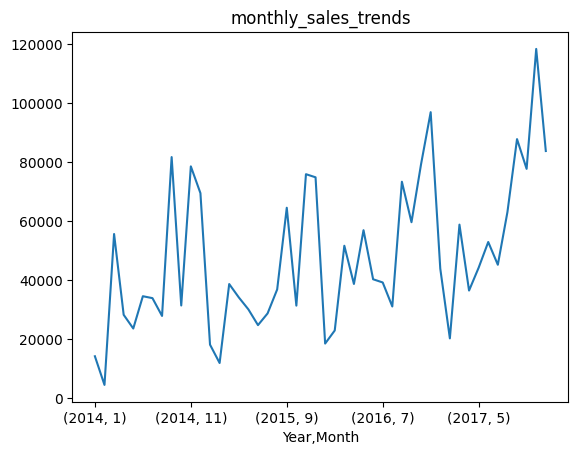

In [48]:
monthly_sales_trends.plot()
plt.title("monthly_sales_trends")
plt.show()

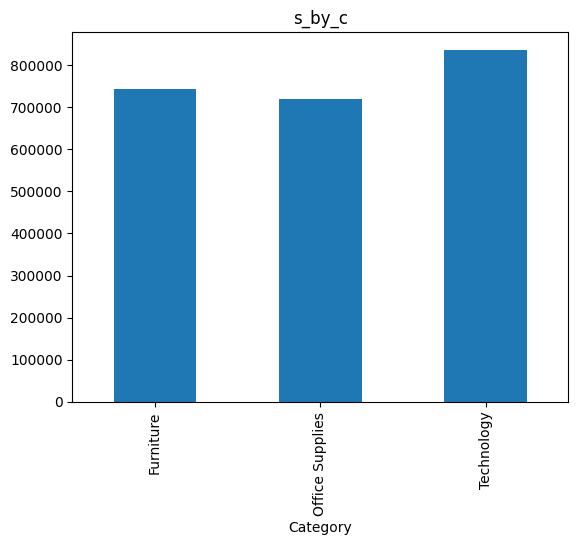

In [49]:
s_by_c.plot(kind='bar')
plt.title("s_by_c")
plt.show()

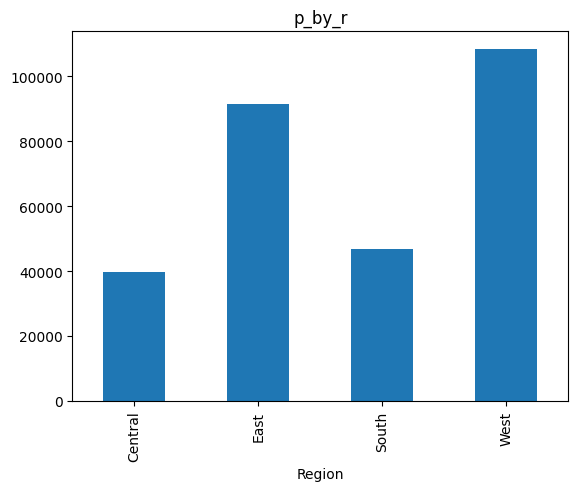

In [50]:
p_by_r.plot(kind='bar')
plt.title("p_by_r")
plt.show()

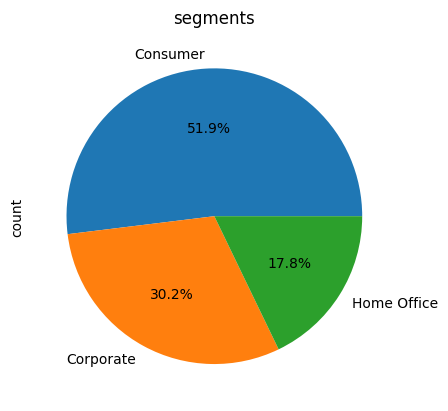

In [51]:
segments=df['Segment'].value_counts()
segments.plot(kind='pie', autopct='%1.1f%%')
plt.title("segments")
plt.show()

In [52]:
# the most profitable catagory
most_profitable_category = df.groupby('Category')['Profit'].sum()
print(most_profitable_category)

print("Most Profitable Category:", most_profitable_category.idxmax())

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64
Most Profitable Category: Technology


Technology is the most profitable catagory

In [53]:
#least performing region
least_region = df.groupby('Region')['Profit'].sum()
print(least_region)

print("Least Performing Region:", least_region.idxmin())

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64
Least Performing Region: Central


central is least performing region

In [54]:
correlation = df['Sales'].corr(df['Profit'])
print("Correlation between Sales and Profit:", correlation)

Correlation between Sales and Profit: 0.4790643497377062


the corr value 0.3 indicates a weak positivr relation ship between profit and sales ,means profit tends to increase with sale but not consistently

In [55]:
trend = df.groupby(['Year', 'Month'])['Sales'].sum()
print(trend)

Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999.0430
2017  1         



* Sales increase toward end of year (Nov–Dec)


* Seasonal patterns exist



* Some months show drops (low demand periods)



